<a href="https://colab.research.google.com/github/kananshr13/CSET-343-Ai-in-Healthcare/blob/main/Lab_Experiment_3_C_CSET_343.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Type - C Image Dataset
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFilter
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Dataset path:", path)

# Locate chest_xray folder
for root, dirs, files in os.walk(path):
    if "train" in dirs and "test" in dirs:
        data_path = root
        break

print("Data path:", data_path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset path: /kaggle/input/chest-xray-pneumonia
Data path: /kaggle/input/chest-xray-pneumonia/chest_xray


In [3]:
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    for label in ["NORMAL", "PNEUMONIA"]:
        folder = os.path.join(data_path, split, label)
        if os.path.exists(folder):
            print(label, ":", len(os.listdir(folder)))


TRAIN
NORMAL : 1341
PNEUMONIA : 3875

VAL
NORMAL : 8
PNEUMONIA : 8

TEST
NORMAL : 234
PNEUMONIA : 390


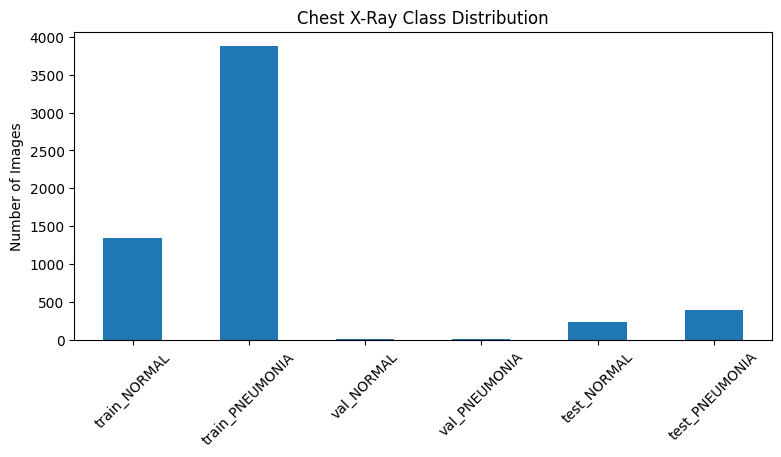

In [4]:
counts = {}

for split in ["train", "val", "test"]:
    for label in ["NORMAL", "PNEUMONIA"]:
        folder = os.path.join(data_path, split, label)
        if os.path.exists(folder):
            counts[f"{split}_{label}"] = len(os.listdir(folder))

pd.Series(counts).plot(kind="bar", figsize=(9,4))
plt.title("Chest X-Ray Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

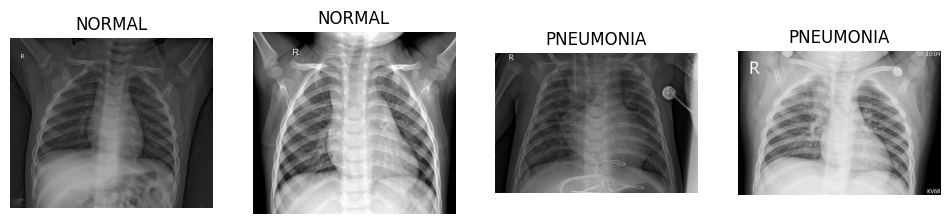

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(12,4))

for i, label in enumerate(["NORMAL", "PNEUMONIA"]):
    folder = os.path.join(data_path, "train", label)
    files = os.listdir(folder)[:2]

    for j, file in enumerate(files):
        img = Image.open(os.path.join(folder, file))
        axes[i*2+j].imshow(img, cmap="gray")
        axes[i*2+j].set_title(label)
        axes[i*2+j].axis("off")

plt.show()

In [6]:
sample = Image.open(
    os.path.join(data_path, "train", "NORMAL",
                 os.listdir(os.path.join(data_path, "train", "NORMAL"))[0])
)

print("Image size:", sample.size)
print("Image mode:", sample.mode)
print("Format:", sample.format)

Image size: (1336, 1128)
Image mode: L
Format: JPEG


In [7]:
# image without original metadata
img = Image.open(
    os.path.join(data_path, "train", "NORMAL",
                 os.listdir(os.path.join(data_path, "train", "NORMAL"))[0])
)

clean_img = Image.new(img.mode, img.size)
clean_img.putdata(list(img.getdata()))

print("Original metadata:", img.info)
print("Metadata removed from processed copy.")

Original metadata: {'exif': b'Exif\x00\x00MM\x00*\x00\x00\x00\x08\x00\x0c\x01\x00\x00\x03\x00\x00\x00\x01\x058\x00\x00\x01\x01\x00\x03\x00\x00\x00\x01\x04h\x00\x00\x01\x02\x00\x03\x00\x00\x00\x04\x00\x00\x00\x9e\x01\x06\x00\x03\x00\x00\x00\x01\x00\x01\x00\x00\x01\x12\x00\x03\x00\x00\x00\x01\x00\x01\x00\x00\x01\x15\x00\x03\x00\x00\x00\x01\x00\x04\x00\x00\x01\x1a\x00\x05\x00\x00\x00\x01\x00\x00\x00\xa6\x01\x1b\x00\x05\x00\x00\x00\x01\x00\x00\x00\xae\x01(\x00\x03\x00\x00\x00\x01\x00\x02\x00\x00\x011\x00\x02\x00\x00\x00 \x00\x00\x00\xb6\x012\x00\x02\x00\x00\x00\x14\x00\x00\x00\xd6\x87i\x00\x04\x00\x00\x00\x01\x00\x00\x00\xec\x00\x00\x01$\x00\x08\x00\x08\x00\x08\x00\x08\x00\n\xfc\x80\x00\x00\'\x10\x00\n\xfc\x80\x00\x00\'\x10Adobe Photoshop CS6 (Macintosh)\x002018:01:04 12:58:55\x00\x00\x00\x00\x04\x90\x00\x00\x07\x00\x00\x00\x040221\xa0\x01\x00\x03\x00\x00\x00\x01\xff\xff\x00\x00\xa0\x02\x00\x04\x00\x00\x00\x01\x00\x00\x058\xa0\x03\x00\x04\x00\x00\x00\x01\x00\x00\x04h\x00\x00\x00\x00\x00\x0

In [8]:
IMG_SIZE = (224, 224)

img = clean_img.convert("L")
img = img.resize(IMG_SIZE)

img_array = np.array(img) / 255.0

print("Processed shape:", img_array.shape)
print("Pixel range:", img_array.min(), "-", img_array.max())

Processed shape: (224, 224)
Pixel range: 0.0 - 0.7176470588235294


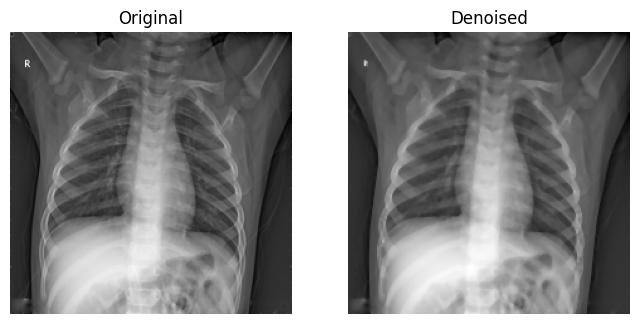

In [9]:
denoised = img.filter(ImageFilter.MedianFilter(size=3))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(denoised, cmap="gray")
plt.title("Denoised")
plt.axis("off")

plt.show()

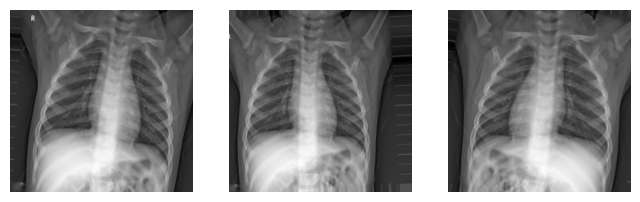

In [10]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

aug_img = np.array(img).reshape(1, 224, 224, 1)

plt.figure(figsize=(8,4))
for i, batch in enumerate(datagen.flow(aug_img, batch_size=1)):
    plt.subplot(1,3,i+1)
    plt.imshow(batch[0].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 2:
        break

plt.show()

In [11]:
from skimage.feature import hog

features = hog(
    img_array,
    orientations=9,
    pixels_per_cell=(16,16),
    cells_per_block=(2,2)
)

print("HOG feature shape:", features.shape)

HOG feature shape: (6084,)


In [12]:
train_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    os.path.join(data_path, "train"),
    target_size=IMG_SIZE,
    color_mode="grayscale",
    class_mode="binary",
    batch_size=32,
    shuffle=True
)

print("Classes:", train_data.class_indices)
print("Images:", train_data.samples)

Found 5216 images belonging to 2 classes.
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}
Images: 5216


In [13]:
print("Image preprocessing completed!")
print("Resize: 224 × 224")
print("Normalization: Pixel values scaled to 0–1")
print("Noise removal: Median filtering")
print("Augmentation: Rotation, shift, zoom, flip")
print("Feature extraction: HOG")
print("Model-ready format: Normalized image tensors")

Image preprocessing completed!
Resize: 224 × 224
Normalization: Pixel values scaled to 0–1
Noise removal: Median filtering
Augmentation: Rotation, shift, zoom, flip
Feature extraction: HOG
Model-ready format: Normalized image tensors
